### NBA Data Mining Project

By Samuel Scott and Yubi Joy Quinzon

Project Objective: Develop a classification model that predicts whether an NBA player will score over or under a
predefined point threshold in a given game. The model leverages historical player performance
data, opponent defensive metrics, and contextual game features to estimate the likelihood of
exceeding the threshold.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as stat
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression #Could use Random Forest or other classification models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [19]:
# import shutil
# import os
# from datetime import datetime
# import kaggle

# # Creating a variable of zip file name that is downloaded from kaggle
# zip_file = 'historical-nba-data-and-player-box-scores.zip'

# # Checks to see if zip file already exists with todays date
# # If file does exists, we skip download
# # If not we delete old zip file and redownload the lastest file
# if os.path.exists(zip_file) and datetime.now().date() == datetime.fromtimestamp(os.path.getmtime(zip_file)).date():
#     print("File has already been download, Skipping!.")

# else:
#     # Remove old files if new date
#     if os.path.exists(zip_file):
#         os.remove(zip_file)

#     if os.path.exists("data"):
#         shutil.rmtree("data")

#     # Using the kaggle api to re-download and unzip
#     !kaggle datasets download -d eoinamoore/historical-nba-data-and-player-box-scores --force
#     !unzip -o historical-nba-data-and-player-box-scores.zip -d data/

# player_stats = pd.read_csv('data/PlayerStatistics.csv', low_memory=False)
# player_stats 

In [20]:
player_stats = pd.read_csv('data/PlayerStatistics.csv', low_memory=False)
player_stats 

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Kevon,Looney,1626172.0,22501128,2026-04-03 22:00:00,New Orleans,Pelicans,Sacramento,Kings,Regular Season,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
1,Drew,Eubanks,1629234.0,22501128,2026-04-03 22:00:00,Sacramento,Kings,New Orleans,Pelicans,Regular Season,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
2,Zion,Williamson,1629627.0,22501128,2026-04-03 22:00:00,New Orleans,Pelicans,Sacramento,Kings,Regular Season,...,0.0,4.0,3.0,0.750,5.0,1.0,6.0,0.0,4.0,-4.0
3,De'Andre,Hunter,1629631.0,22501128,2026-04-03 22:00:00,Sacramento,Kings,New Orleans,Pelicans,Regular Season,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
4,Jordan,Poole,1629673.0,22501128,2026-04-03 22:00:00,New Orleans,Pelicans,Sacramento,Kings,Regular Season,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1665610,Tanner,Krebs,196295485.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.0,0.0,0.0,0.000,1.0,1.0,2.0,2.0,0.0,-10.0
1665611,Fabijan,Krslovic,196295487.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.0,4.0,3.0,0.750,1.0,2.0,3.0,1.0,1.0,-21.0
1665612,Nicholas,Tata,196295488.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.0,0.0,0.0,0.000,1.0,1.0,2.0,3.0,1.0,-8.0
1665613,Austin,Wiley,196295491.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.0,7.0,6.0,0.857,7.0,4.0,11.0,3.0,1.0,0.0


In [21]:
# Column information of data - some type inconsistentcies like date (in the form of a string)
player_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1665615 entries, 0 to 1665614
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   firstName                1665381 non-null  str    
 1   lastName                 1665377 non-null  str    
 2   personId                 1665570 non-null  float64
 3   gameId                   1665615 non-null  int64  
 4   gameDateTimeEst          1661887 non-null  str    
 5   playerteamCity           1665447 non-null  str    
 6   playerteamName           1661887 non-null  str    
 7   opponentteamCity         1661719 non-null  str    
 8   opponentteamName         1661887 non-null  str    
 9   gameType                 1665565 non-null  str    
 10  gameLabel                96782 non-null    str    
 11  gameSubLabel             6497 non-null     str    
 12  seriesGameNumber         135048 non-null   float64
 13  win                      1661877 non-null  float64
 1

In [22]:
# Size of our data
player_stats.shape

(1665615, 35)

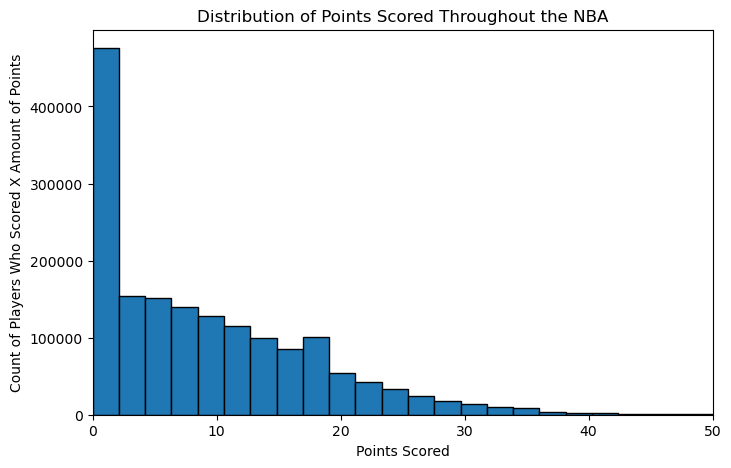

In [23]:
#Shows distribution of points across the NBA history.
points = player_stats['points']

plt.figure(figsize=(8,5))
plt.hist(points, bins=50, edgecolor='black')
plt.title("Distribution of Points Scored Throughout the NBA")
plt.xlabel("Points Scored")
plt.ylabel("Count of Players Who Scored X Amount of Points")
plt.xlim(0, 50) #Set a limit to 50 points since scoring above 50 is a rare feat in the NBA. 
plt.show()

In [24]:
# Count nulls per attribute
null_counts = player_stats.isnull().sum()
null_counts.sort_values(ascending=False)

gameSubLabel               1659118
gameLabel                  1568833
seriesGameNumber           1530567
numMinutes                  168442
opponentteamCity              3896
win                           3738
gameDateTimeEst               3728
home                          3728
opponentteamName              3728
playerteamName                3728
plusMinusPoints               2666
freeThrowsAttempted           1718
freeThrowsMade                1718
reboundsDefensive             1718
assists                       1718
blocks                        1718
fieldGoalsMade                1718
steals                        1718
points                        1718
reboundsOffensive             1718
reboundsTotal                 1718
foulsPersonal                 1718
fieldGoalsAttempted           1718
threePointersAttempted        1718
threePointersMade             1718
threePointersPercentage       1718
fieldGoalsPercentage          1718
turnovers                     1718
freeThrowsPercentage

In [25]:
# Types of games - we should only care about regular season and playoffs
player_stats['gameType'].unique().tolist()

['Regular Season',
 'All-Star Game',
 nan,
 'Emirates NBA Cup',
 'in-season-knockout',
 'Preseason',
 'Playoffs',
 'Play-in Tournament',
 'NBA Cup',
 'NBA Emirates Cup',
 'Pre Season']

In [26]:
# Shows that games will null values in date time are tied to only preseason games which we will drop
player_stats[player_stats['gameDateTimeEst'].isnull()]['gameType'].unique().tolist()

['Pre Season']

In [27]:
# Dropping null values 
player_stats = player_stats.dropna(subset=["personId", "gameId", "numMinutes", "gameType"])

In [28]:
# Dropping unserious game types
player_stats = player_stats[~player_stats["gameType"].isin(["Preseason", "All-Star Game", "Pre Season"])]

In [29]:
# Capturing user-input for Point Threshold - turn on later or add in code when running 

#while True:
#    try:
#        point_threshold = float(input("Enter point threshold: "))
#        break
#    except ValueError:
#        print("Please enter a valid number.")
point_threshold = 10

In [30]:
# Changing date type from string to datetime
player_stats["gameDateTimeEst"] = pd.to_datetime(player_stats["gameDateTimeEst"])

In [31]:
# Count nulls per attribute - notice we reduced most of our nulls
null_counts = player_stats.isnull().sum()
null_counts[null_counts > 0]

gameLabel           1370683
gameSubLabel        1440948
seriesGameNumber    1331040
dtype: int64

In [32]:
# Here we are creating our target variable, determines if the record is over or under the point threshold
# Using numpy for efficiency
player_stats["threshold_10"] = np.where(player_stats["points"] > point_threshold, 1, 0)
player_stats["threshold_15"] = np.where(player_stats["points"] > point_threshold + 5, 1, 0)
player_stats["threshold_20"] = np.where(player_stats["points"] > point_threshold + 10, 1, 0)
player_stats["threshold_25"] = np.where(player_stats["points"] > point_threshold + 15, 1, 0)

In [33]:
rolling_average_stats = player_stats

# Sorting our data by player and date to calculate rolling averages
rolling_average_stats = rolling_average_stats.sort_values(["personId", "gameDateTimeEst"])
groupby_personid = rolling_average_stats.groupby("personId")

rolling_average_stats["rolling_avg_points"] = groupby_personid["points"].transform(
    lambda x: # X is the current metric (points in this case)
    x.shift(1). # Shift will move all values up (data in ascending order) so each record will start with previous points  
    rolling(5). # Take acount of the last 5 games
    mean() # takes the average of those last 5 games
)

rolling_average_stats["rolling_avg_fg_percent"] = groupby_personid["fieldGoalsPercentage"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_min"] = groupby_personid["numMinutes"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_fga"] = groupby_personid["fieldGoalsAttempted"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_turnovers"] = groupby_personid["turnovers"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_fta"] = groupby_personid["freeThrowsAttempted"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_3pt_percent"] = groupby_personid["threePointersPercentage"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

In [34]:
# Because rolling averages dont account for the first 5 games, we remove them
rolling_average_stats = rolling_average_stats.dropna(subset=[
    "rolling_avg_points",
    "rolling_avg_fg_percent",
    "rolling_avg_min",
    "rolling_avg_fga",
    "rolling_avg_turnovers",
    "rolling_avg_fta",
    "rolling_avg_3pt_percent"
])

last_10_years_data = rolling_average_stats[rolling_average_stats["gameDateTimeEst"] >= "2015-10-26"]
last_10_years_data

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threshold_15,threshold_20,threshold_25,rolling_avg_points,rolling_avg_fg_percent,rolling_avg_min,rolling_avg_fga,rolling_avg_turnovers,rolling_avg_fta,rolling_avg_3pt_percent
388092,Kevin,Garnett,708.0,21500017,2015-10-28 22:30:00,Minnesota,Timberwolves,Los Angeles,Lakers,Regular Season,...,0,0,0,7.6,0.5938,19.200,6.2,0.2,0.8,0.0000
387782,Kevin,Garnett,708.0,21500029,2015-10-30 21:00:00,Minnesota,Timberwolves,Denver,Nuggets,Regular Season,...,0,0,0,7.4,0.6366,18.000,5.6,0.2,0.4,0.0000
387264,Kevin,Garnett,708.0,21500050,2015-11-02 20:00:00,Minnesota,Timberwolves,Portland,Trail Blazers,Regular Season,...,0,0,0,7.0,0.5532,19.400,5.4,0.2,0.8,0.0000
386721,Kevin,Garnett,708.0,21500071,2015-11-05 20:00:00,Minnesota,Timberwolves,Miami,Heat,Regular Season,...,0,0,0,4.6,0.4332,18.400,4.0,0.2,1.2,0.0000
386333,Kevin,Garnett,708.0,21500085,2015-11-07 18:00:00,Minnesota,Timberwolves,Chicago,Bulls,Regular Season,...,0,0,0,2.4,0.2666,16.400,3.0,0.2,0.8,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,Chaney,Johnson,1643052.0,22501100,2026-03-31 19:30:00,Brooklyn,Nets,Charlotte,Hornets,Regular Season,...,0,0,0,7.2,0.5166,16.664,5.0,1.6,1.2,0.2666
159,Chaney,Johnson,1643052.0,22501122,2026-04-03 19:30:00,Brooklyn,Nets,Atlanta,Hawks,Regular Season,...,0,0,0,8.0,0.5834,18.832,5.6,1.6,0.8,0.1332
24076,Jahmyl,Telfort,1643141.0,22500278,2025-11-23 18:00:00,LA,Clippers,Cleveland,Cavaliers,Regular Season,...,0,0,0,0.2,0.0000,4.564,0.6,0.2,0.8,0.0000
23608,Jahmyl,Telfort,1643141.0,22500059,2025-11-25 23:00:00,LA,Clippers,Los Angeles,Lakers,Regular Season,...,0,0,0,0.2,0.0000,4.722,0.8,0.2,0.8,0.0000


In [35]:
# Correlation metric for scoring flag!
last_10_years_data.corr(numeric_only=True)['threshold_10'].sort_values(ascending=False)

# Obviously we must remove points, fg made, ft made, 3pt made

threshold_10               1.000000
points                     0.804496
fieldGoalsMade             0.785372
fieldGoalsAttempted        0.725513
threshold_15               0.667472
rolling_avg_fga            0.576432
rolling_avg_points         0.567366
threePointersMade          0.526753
rolling_avg_min            0.523642
freeThrowsMade             0.500023
freeThrowsAttempted        0.497701
threePointersAttempted     0.496389
threshold_20               0.454199
rolling_avg_fta            0.452218
freeThrowsPercentage       0.442199
rolling_avg_turnovers      0.436746
assists                    0.385391
reboundsDefensive          0.384178
reboundsTotal              0.378159
turnovers                  0.353813
threePointersPercentage    0.339379
fieldGoalsPercentage       0.337890
threshold_25               0.305947
steals                     0.239317
foulsPersonal              0.236131
rolling_avg_3pt_percent    0.210618
reboundsOffensive          0.192912
rolling_avg_fg_percent     0

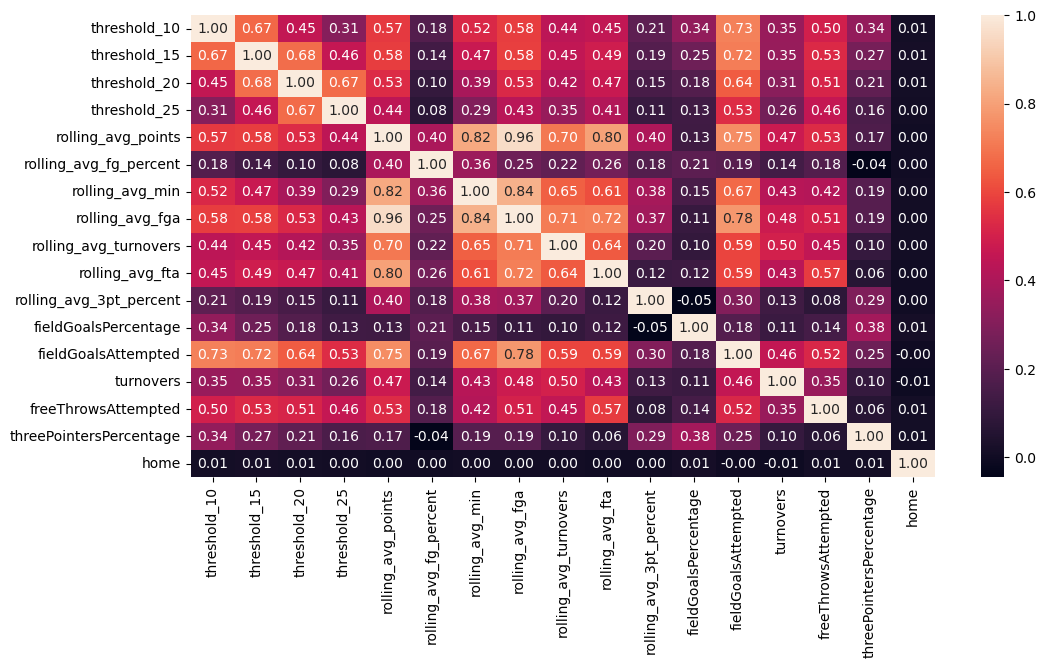

In [36]:
#Deciding on which features to display is important as we are trying to show all audiences what the most important features are and why
corr_features = [
    "threshold_10",
    "threshold_15",
    "threshold_20",
    "threshold_25",
    "rolling_avg_points",
    "rolling_avg_fg_percent",
    "rolling_avg_min",
    "rolling_avg_fga",
    "rolling_avg_turnovers",
    "rolling_avg_fta",
    "rolling_avg_3pt_percent",
    "fieldGoalsPercentage",
    "numMinutes",
    "fieldGoalsAttempted",
    "turnovers",
    "freeThrowsAttempted",
    "threePointersPercentage", 
    "home"
]

plt.figure(figsize=(12,6))
sns.heatmap(last_10_years_data[corr_features].corr(numeric_only=True), annot=True, fmt=".2f")
plt.show()

In [37]:
last_10_years_data.corr(numeric_only=True)['threshold_15'].sort_values(ascending=False)

threshold_15               1.000000
points                     0.809912
fieldGoalsMade             0.781713
fieldGoalsAttempted        0.716294
threshold_20               0.680476
threshold_10               0.667472
rolling_avg_fga            0.581091
rolling_avg_points         0.578569
freeThrowsMade             0.538272
freeThrowsAttempted        0.528001
threePointersMade          0.513417
rolling_avg_fta            0.486048
threePointersAttempted     0.477837
rolling_avg_min            0.472433
threshold_25               0.458366
rolling_avg_turnovers      0.449678
freeThrowsPercentage       0.384397
assists                    0.377837
turnovers                  0.347139
reboundsDefensive          0.336466
reboundsTotal              0.321217
threePointersPercentage    0.271925
fieldGoalsPercentage       0.249510
steals                     0.207770
rolling_avg_3pt_percent    0.185867
foulsPersonal              0.181520
plusMinusPoints            0.165873
reboundsOffensive          0

In [38]:
last_10_years_data.corr(numeric_only=True)['threshold_20'].sort_values(ascending=False)

threshold_20               1.000000
points                     0.743651
fieldGoalsMade             0.707135
threshold_15               0.680476
threshold_25               0.673596
fieldGoalsAttempted        0.644052
rolling_avg_points         0.530803
freeThrowsMade             0.529256
rolling_avg_fga            0.525969
freeThrowsAttempted        0.513313
rolling_avg_fta            0.468714
threePointersMade          0.461716
threshold_10               0.454199
threePointersAttempted     0.426865
rolling_avg_turnovers      0.416751
rolling_avg_min            0.388780
assists                    0.339158
turnovers                  0.314374
freeThrowsPercentage       0.308855
reboundsDefensive          0.278335
reboundsTotal              0.257823
threePointersPercentage    0.213749
fieldGoalsPercentage       0.180596
steals                     0.169824
rolling_avg_3pt_percent    0.152438
plusMinusPoints            0.147847
foulsPersonal              0.134395
rolling_avg_fg_percent     0

In [39]:
last_10_years_data.corr(numeric_only=True)['threshold_25'].sort_values(ascending=False)

threshold_25               1.000000
threshold_20               0.673596
points                     0.633833
fieldGoalsMade             0.594671
fieldGoalsAttempted        0.534703
freeThrowsMade             0.478048
freeThrowsAttempted        0.460143
threshold_15               0.458366
rolling_avg_points         0.442465
rolling_avg_fga            0.429002
rolling_avg_fta            0.412137
threePointersMade          0.385462
threePointersAttempted     0.352296
rolling_avg_turnovers      0.349957
threshold_10               0.305947
rolling_avg_min            0.294340
assists                    0.277539
turnovers                  0.262704
freeThrowsPercentage       0.228659
reboundsDefensive          0.219644
reboundsTotal              0.198322
threePointersPercentage    0.159595
steals                     0.134822
fieldGoalsPercentage       0.130377
plusMinusPoints            0.119005
rolling_avg_3pt_percent    0.113046
foulsPersonal              0.096793
rolling_avg_fg_percent     0

388092   -3.6
387782   -3.4
387264   -7.0
386721   -4.6
386333   -0.4
         ... 
813       3.8
159       3.0
24076    -0.2
23608    -0.2
22168    -0.2
Name: point_diff, Length: 292690, dtype: float64

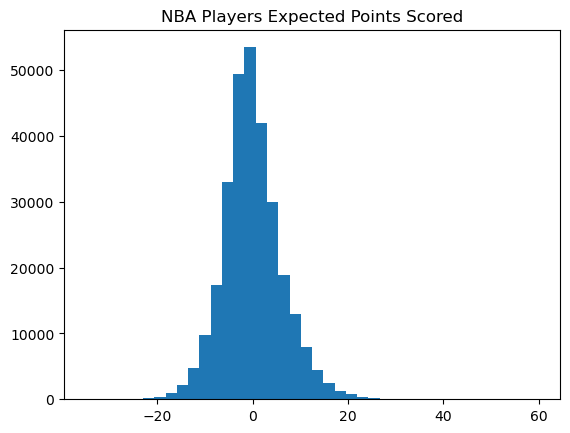

In [ ]:
#Outlier detection (Early workings of it)
last_10_years_data['point_diff'] = (last_10_years_data['points'] - last_10_years_data['rolling_avg_points'])

plt.hist(last_10_years_data['point_diff'], bins=40)
plt.title("NBA Players Expected Points Scored")
plt.xlabel("")

last_10_years_data['point_diff']